# 🧪 실험 1: Baseline CNN (직접 설계)

**목적**: 단순 CNN으로 반려동물 피부 질환 7클래스 분류가 가능한지 기준선(Baseline) 성능 확인  
**입력**: 반려동물 피부 사진 (224×224×3)  
**출력**: 7개 질환 클래스별 확률  
**데이터**: 정규화만 적용 (증강 없음)  
**모델**: Conv2D 4블록 직접 설계

---


## 0. 라이브러리 임포트 및 설정

모델 학습에 필요한 라이브러리들을 불러옵니다.

| 라이브러리 | 역할 |
|-----------|------|
| `tensorflow / keras` | 딥러닝 모델 구축 및 학습 |
| `pandas` | CSV 데이터 로딩 |
| `numpy` | 수치 연산 |
| `matplotlib / seaborn` | 그래프 시각화 |
| `sklearn.metrics` | 분류 성능 평가 (F1-Score, Confusion Matrix) |


In [1]:
import os                          # 파일/폴더 경로 처리용
import numpy as np                 # 수치 연산 (배열, 행렬)
import pandas as pd                # 데이터프레임 (CSV 읽기)
import matplotlib.pyplot as plt    # 그래프 시각화
from pathlib import Path           # 경로를 객체로 다루는 유틸리티

import tensorflow as tf            # 딥러닝 프레임워크 (텐서플로)
from tensorflow import keras       # 텐서플로의 고수준 API (케라스)

# keras에서 필요한 모듈들을 개별 임포트
from keras.models import Sequential          # 레이어를 순서대로 쌓는 모델 구조
from keras.layers import (
    Conv2D,                # 합성곱 레이어: 이미지에서 특징(패턴)을 추출
    MaxPooling2D,          # 최대 풀링: 특징맵 크기를 줄여 연산량 감소
    BatchNormalization,    # 배치 정규화: 학습 안정화, 수렴 속도 향상
    Flatten,               # 2D 특징맵 → 1D 벡터로 변환
    Dense,                 # 완전연결층: 최종 분류 수행
    Dropout,               # 드롭아웃: 과적합 방지 (일부 뉴런 비활성화)
    GlobalAveragePooling2D # 전역 평균 풀링: Flatten 대신 사용, 파라미터 수 감소
)

from keras.callbacks import (
    EarlyStopping,         # 조기 종료: val_loss 개선 없으면 학습 중단
    ModelCheckpoint,       # 체크포인트: 최고 성능 모델 자동 저장
    ReduceLROnPlateau      # 학습률 감소: val_loss 정체 시 lr을 줄여 미세 조정
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator  # 이미지 데이터 로딩 + 증강

# 학습 곡선 외 평가 지표
from sklearn.metrics import classification_report, confusion_matrix  # 분류 리포트, 혼동 행렬
import seaborn as sns              # 히트맵 등 고급 시각화

# 한글 폰트 설정 (Windows 환경)
plt.rcParams['font.family'] = 'Malgun Gothic'    # 맑은 고딕 폰트 사용
plt.rcParams['axes.unicode_minus'] = False        # 마이너스(-) 기호 깨짐 방지

print(f"TensorFlow 버전: {tf.__version__}")
print(f"GPU 사용 가능: {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow 버전: 2.21.0
GPU 사용 가능: False


In [2]:
# ── CPU 성능 최적화 (i7-10700K: 8코어 / 16스레드) ──
tf.config.threading.set_intra_op_parallelism_threads(16)
tf.config.threading.set_inter_op_parallelism_threads(8)
tf.config.optimizer.set_jit(True)  # XLA JIT 컴파일 활성화

print(f"intra_op threads : {tf.config.threading.get_intra_op_parallelism_threads()}")
print(f"inter_op threads : {tf.config.threading.get_inter_op_parallelism_threads()}")
print("XLA JIT 컴파일   : 활성화")

intra_op threads : 16
inter_op threads : 8
XLA JIT 컴파일   : 활성화


## 1. 경로 설정 및 데이터 로딩

전처리 단계에서 만든 `dataset_cleaned.csv`를 불러와 train/val/test로 분리합니다.

| 경로 | 용도 |
|------|------|
| `PROCESSED` | 전처리된 CSV 파일 위치 (`data/processed/`) |
| `FIG_DIR` | 학습 곡선, 혼동 행렬 등 그래프 저장 위치 |
| `MODEL_DIR` | 학습된 모델 파일(.h5) 저장 위치 |

> ⚠️ 이 노트북은 `D:\SAG\models\` 에서 실행하는 기준입니다.  
> `notebooks/`에서 실행하려면 `ROOT = Path('..')`은 동일합니다.


In [3]:
# 프로젝트 루트 경로 (이 파일이 models/ 안에 있으므로 ..으로 한 단계 위)
ROOT = Path('..')

# 전처리된 CSV가 있는 폴더
PROCESSED = ROOT / 'data' / 'processed'

# 그래프 저장 폴더 (없으면 자동 생성)
FIG_DIR = ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 모델 저장 폴더 (없으면 자동 생성)
MODEL_DIR = ROOT / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"프로젝트 루트  : {ROOT.resolve()}")
print(f"CSV 경로      : {PROCESSED.resolve()}")
print(f"그래프 저장    : {FIG_DIR.resolve()}")
print(f"모델 저장      : {MODEL_DIR.resolve()}")


프로젝트 루트  : D:\SAG
CSV 경로      : D:\SAG\data\processed
그래프 저장    : D:\SAG\outputs\figures
모델 저장      : D:\SAG\models


### 1-1. CSV 불러오기 및 Train/Val/Test 분리

`dataset_cleaned.csv`에는 이미 `split` 컬럼이 있어서 바로 분리할 수 있습니다.

| split | 수량 | 비율 | 용도 |
|-------|------|------|------|
| train | 24,500 | 70% | 모델 학습용 |
| val | 5,250 | 15% | 학습 중 검증용 (과적합 모니터링) |
| test | 5,250 | 15% | 최종 성능 평가용 (학습에 절대 사용 안 함) |


In [4]:
# dataset_cleaned.csv: 전처리 완료된 34,987개 샘플 정보
df = pd.read_csv(PROCESSED / 'dataset_cleaned.csv')

# 이미지 경로 컬럼 지정 (원본 이미지 경로 사용)
target_col = 'img_path'

# split 컬럼으로 train/val/test 분리
# .copy()로 복사본 생성 → 원본 df에 영향 없음
df_train = df[df['split'] == 'train'].copy()   # 24,500개 (70%)
df_val   = df[df['split'] == 'val'].copy()     # 5,250개  (15%)
df_test  = df[df['split'] == 'test'].copy()    # 5,250개  (15%)

print(f"✅ 데이터 로드 완료")
print(f"  train : {len(df_train):,}장")
print(f"  val   : {len(df_val):,}장")
print(f"  test  : {len(df_test):,}장")
print(f"  전체  : {len(df):,}장")


✅ 데이터 로드 완료
  train : 24,492장
  val   : 5,249장
  test  : 5,246장
  전체  : 34,987장


## 2. 하이퍼파라미터 설정

모델 학습에 사용되는 주요 설정값들입니다. 이 값들을 바꾸면 학습 결과가 달라집니다.

| 파라미터 | 값 | 설명 |
|---------|-----|------|
| `IMG_SIZE` | (128, 128) | CNN에 입력되는 이미지 크기 (가로×세로 픽셀) |
| `BATCH_SIZE` | 64 | 한 번에 모델에 넣는 이미지 수 (GPU 메모리에 따라 조절) |
| `EPOCHS` | 20 | 전체 데이터를 최대 몇 번 반복 학습할지 (EarlyStopping으로 조기 종료 가능) |
| `NUM_CLASSES` | 7 | 분류할 질환 클래스 수 (A1~A7) |
| `LEARNING_RATE` | 0.001 | 가중치 업데이트 크기 (너무 크면 발산, 너무 작으면 느림) |


In [ ]:
IMG_SIZE      = (128, 128)   # CNN 입력 이미지 크기 (224→128, 연산량 ~3배 감소)
BATCH_SIZE    = 64           # 한 번에 모델에 넣는 이미지 수
EPOCHS        = 20           # 전체 데이터를 최대 30번 반복 학습
NUM_CLASSES   = 7            # 분류할 질환 클래스 수 (A1~A7)
LEARNING_RATE = 0.001        # 학습률: 가중치 업데이트 크기

print(f"이미지 크기  : {IMG_SIZE}")
print(f"배치 크기    : {BATCH_SIZE}")
print(f"최대 에폭    : {EPOCHS}")
print(f"클래스 수    : {NUM_CLASSES}")
print(f"학습률       : {LEARNING_RATE}")


이미지 크기  : (128, 128)
배치 크기    : 32
최대 에폭    : 20
클래스 수    : 7
학습률       : 0.001


## 3. 데이터 Generator 생성

`ImageDataGenerator`는 이미지 파일을 배치 단위로 읽어와 모델에 전달하는 역할입니다.

**실험 1은 Baseline**이므로 **증강(Augmentation) 없이 정규화(rescale)만** 적용합니다.

- `rescale=1./255`: 픽셀값 0~255를 0~1 범위로 변환 → 모든 입력을 같은 스케일로 맞춰 학습 안정화
- Val/Test 데이터는 항상 증강하지 않음 → 원본 그대로 평가해야 공정


In [6]:
# ── Train용 Generator: 정규화만 적용 (증강 없음 = 실험 1 핵심) ──
train_datagen = ImageDataGenerator(
    rescale=1./255     # 픽셀값 0~255 → 0~1 범위로 변환
)

# ── Val/Test용 Generator: 동일하게 정규화만 ──
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("✅ ImageDataGenerator 정의 완료 (정규화만, 증강 없음)")


✅ ImageDataGenerator 정의 완료 (정규화만, 증강 없음)


### 3-1. flow_from_dataframe — DataFrame에서 이미지 로딩

`flow_from_dataframe`은 DataFrame의 이미지 경로를 읽어 배치 단위로 모델에 전달합니다.

| 파라미터 | 설명 |
|---------|------|
| `x_col` | 이미지 파일 경로가 있는 컬럼명 |
| `y_col` | 라벨(정답)이 있는 컬럼명 → `'lesion'` (A1~A7) |
| `target_size` | 이미지를 이 크기로 리사이즈 |
| `class_mode='categorical'` | 원핫인코딩 (A1 = [1,0,0,0,0,0,0]) |
| `shuffle=True` | 매 에폭마다 순서 섞기 (train만, 과적합 방지) |
| `shuffle=False` | Val/Test는 순서 유지 (평가 일관성) |
| `seed=42` | 랜덤 시드 고정 (재현성 확보) |


In [7]:
# ── Train Generator ──
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col=target_col,          # 이미지 파일 경로 컬럼
    y_col='lesion',            # 라벨 컬럼 (A1~A7)
    target_size=IMG_SIZE,      # (224, 224)로 리사이즈
    batch_size=BATCH_SIZE,     # 32장씩 묶어서 전달
    class_mode='categorical',  # 원핫인코딩 방식
    shuffle=True,              # 데이터 순서 섞기
    seed=42                    # 재현성을 위한 시드 고정
)

# ── Validation Generator ──
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col=target_col,
    y_col='lesion',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False              # 검증 데이터는 순서 유지
)

# ── Test Generator ──
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col=target_col,
    y_col='lesion',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False              # 테스트 데이터도 순서 유지
)

# 클래스 인덱스 확인: 어떤 클래스가 어떤 번호에 매핑되었는지
print(f"\n✅ Generator 생성 완료")
print(f"클래스 인덱스: {train_generator.class_indices}")
print(f"Train 배치 수: {len(train_generator)}")
print(f"Val 배치 수  : {len(val_generator)}")
print(f"Test 배치 수 : {len(test_generator)}")


Found 24492 validated image filenames belonging to 7 classes.
Found 5249 validated image filenames belonging to 7 classes.
Found 5246 validated image filenames belonging to 7 classes.

✅ Generator 생성 완료
클래스 인덱스: {'A1': 0, 'A2': 1, 'A3': 2, 'A4': 3, 'A5': 4, 'A6': 5, 'A7': 6}
Train 배치 수: 766
Val 배치 수  : 165
Test 배치 수 : 164


## 3-2. tf.data 파이프라인 (성능 최적화)

`ImageDataGenerator` 대신 `tf.data` API를 사용합니다. 기존 Generator 코드는 참조용으로 유지됩니다.

| 기능 | 효과 |
|------|------|
| `num_parallel_calls=AUTOTUNE` | CPU 멀티스레드 병렬 이미지 로딩 |
| `.cache()` | 32GB RAM에 전처리 결과 캐시 → 2회차 에폭부터 디스크 I/O 없음 |
| `.prefetch(AUTOTUNE)` | 다음 배치를 학습 중에 미리 준비 |

In [8]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

AUTOTUNE = tf.data.AUTOTUNE

# 라벨 인코더: A1~A7 알파벳 순 (train_generator.class_indices와 동일 순서)
le = LabelEncoder()
le.fit(sorted(df_train['lesion'].unique()))

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_dataset(df, shuffle=False):
    paths = df[target_col].values
    labels = to_categorical(le.transform(df['lesion']), num_classes=NUM_CLASSES).astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()          # 32GB RAM에 전처리 결과 캐시
    if shuffle:
        ds = ds.shuffle(buffer_size=2048, seed=42)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_dataset = make_dataset(df_train, shuffle=True)
val_dataset   = make_dataset(df_val,   shuffle=False)
test_dataset  = make_dataset(df_test,  shuffle=False)

print("✅ tf.data 파이프라인 완료")
print(f"  클래스 순서  : {list(le.classes_)}")
print(f"  Train 배치 수: {len(train_dataset)}")
print(f"  Val 배치 수  : {len(val_dataset)}")
print(f"  Test 배치 수 : {len(test_dataset)}")

✅ tf.data 파이프라인 완료
  클래스 순서  : [np.str_('A1'), np.str_('A2'), np.str_('A3'), np.str_('A4'), np.str_('A5'), np.str_('A6'), np.str_('A7')]
  Train 배치 수: 766
  Val 배치 수  : 165
  Test 배치 수 : 164


## 4. Baseline CNN 모델 구조 정의

`Sequential` 모델로 레이어를 위에서 아래로 순서대로 쌓습니다.

### 구조 요약

```
입력 (128×128×3)
    ↓
[블록1] Conv2D(32) → BatchNorm → ReLU → MaxPool → 112×112×32
    ↓
[블록2] Conv2D(64) → BatchNorm → ReLU → MaxPool → 56×56×64
    ↓
[블록3] Conv2D(128) → BatchNorm → ReLU → MaxPool → 28×28×128
    ↓
[블록4] Conv2D(256) → BatchNorm → ReLU → MaxPool → 14×14×256
    ↓
GlobalAveragePooling2D → 256차원 벡터
    ↓
Dense(256) → Dropout(0.5) → Dense(7, softmax)
    ↓
출력: [A1확률, A2확률, A3확률, A4확률, A5확률, A6확률, A7확률]
```

### 각 레이어 역할

| 레이어 | 역할 |
|--------|------|
| **Conv2D** | 3×3 필터로 이미지를 훑으며 특징(패턴) 추출. 필터 수가 늘수록 복잡한 패턴 감지 |
| **BatchNormalization** | 각 배치의 출력값을 정규화 → 학습이 안정적이고 빠르게 수렴 |
| **MaxPooling2D** | 2×2 영역에서 최댓값만 남김 → 크기 절반 축소, 중요 특징만 보존 |
| **GlobalAveragePooling2D** | 특징맵 전체를 평균하여 1D 벡터로 압축. Flatten보다 파라미터 적어 과적합 방지 |
| **Dense** | 완전연결층. 추출된 특징을 조합하여 최종 분류 |
| **Dropout(0.5)** | 학습 중 뉴런 50%를 랜덤 비활성화 → 과적합 방지 |
| **softmax** | 7개 출력값의 합을 1.0으로 만듦 → 각 클래스의 확률로 해석 가능 |


In [9]:
model = Sequential([

    # ── 블록 1: 기본 특징 추출 (엣지, 색상 변화 감지) ──
    # Conv2D(32, (3,3)): 3×3 크기의 필터 32개로 이미지를 훑으며 특징 추출
    # padding='same': 입력과 출력 크기를 동일하게 유지
    # activation='relu': 음수 → 0, 양수 → 그대로 (비선형성 부여)
    # input_shape: 첫 번째 레이어에만 입력 크기 명시 (IMG_SIZE 기준)
    Conv2D(32, (3, 3), padding='same', activation='relu',
           input_shape=(*IMG_SIZE, 3)),
    BatchNormalization(),      # 출력값 정규화 → 학습 안정화
    MaxPooling2D((2, 2)),      # 224×224 → 112×112 (크기 절반 축소)

    # ── 블록 2: 중간 수준 특징 (질감, 패턴 조합) ──
    # 필터 수 32→64로 증가: 블록1의 기본 특징을 조합하여 더 복잡한 패턴 학습
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),      # 112×112 → 56×56

    # ── 블록 3: 고수준 특징 (질감, 색상 패턴 복합) ──
    # 필터 수 64→128: 피부의 질감, 색상 변화 등 고수준 특징 학습
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),      # 56×56 → 28×28

    # ── 블록 4: 질환 특화 특징 (질환별 고유 패턴) ──
    # 필터 수 128→256: 질환별 특화된 복합 패턴 학습
    # 예: "붉은 울퉁불퉁한 영역" = A1 구진, "하얀 거친 표면" = A2 비듬
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),      # 28×28 → 14×14

    # ── 분류 헤드 (Classification Head) ──
    # GlobalAveragePooling2D: 14×14×256 특징맵 → 256차원 벡터로 압축
    # Flatten 대신 사용하는 이유: 파라미터 수가 훨씬 적어 과적합 방지
    GlobalAveragePooling2D(),

    # Dense(256): 256개 뉴런의 완전연결층
    # 추출된 특징들을 조합하여 최종 판단 준비
    Dense(256, activation='relu'),

    # Dropout(0.5): 학습 중 뉴런의 50%를 랜덤으로 끔
    # → 특정 뉴런에 의존하지 않도록 하여 과적합 방지
    Dropout(0.5),

    # Dense(7, softmax): 최종 출력층
    # 7개 클래스에 대한 확률 출력 (합계 = 1.0)
    # 예: [0.03, 0.02, 0.02, 0.87, 0.03, 0.02, 0.01]
    Dense(NUM_CLASSES, activation='softmax')
])

print("✅ 모델 구조 정의 완료")


✅ 모델 구조 정의 완료


c:\Users\금정산2-PC01\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 5. 모델 컴파일

모델 구조를 정의한 후, **어떻게 학습할지** 설정하는 단계입니다.

| 설정 | 값 | 설명 |
|------|-----|------|
| `optimizer` | Adam(lr=0.001) | 가중치를 어떻게 업데이트할지. Adam은 학습률을 자동 조절하는 가장 범용적인 옵티마이저 |
| `loss` | categorical_crossentropy | 예측과 정답의 차이를 측정. 원핫인코딩된 다중 클래스 분류에 사용 |
| `metrics` | accuracy | 학습 중 모니터링할 지표. 전체 예측 중 맞춘 비율 |


In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),  # Adam 옵티마이저
    loss='categorical_crossentropy',    # 다중 클래스 분류 손실 함수
    metrics=['accuracy']                # 정확도 모니터링
)

# 모델 구조 요약 출력: 레이어별 출력 크기와 파라미터 수 확인
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,927 (1.75 MB)

 Trainable params: 456,967 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. 콜백(Callbacks) 설정

학습 도중 **자동으로 실행**되는 기능들입니다. 수동으로 학습을 멈추거나 모델을 저장할 필요 없이 알아서 처리해줍니다.

| 콜백 | 역할 |
|------|------|
| **EarlyStopping** | val_loss가 5 에폭 연속 개선 안 되면 학습 자동 중단. 과적합 방지 |
| **ModelCheckpoint** | 매 에폭마다 val_loss가 최소인 모델을 파일(.h5)로 자동 저장 |
| **ReduceLROnPlateau** | val_loss가 3 에폭 정체되면 학습률을 절반으로 줄여 미세 조정 |


In [11]:
callbacks = [
    # val_loss가 5 에폭 연속 개선 안 되면 학습 중단
    # restore_best_weights=True: 중단 시 가장 좋았던 가중치로 복원
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # val_loss가 최소인 모델을 파일로 자동 저장
    # save_best_only=True: 최고 성능일 때만 저장 (디스크 절약)
    ModelCheckpoint(
        filepath=str(MODEL_DIR / 'exp1_baseline.h5'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),

    # val_loss가 3 에폭 정체되면 학습률을 절반(factor=0.5)으로 줄임
    # min_lr: 최소 학습률 (이 이하로는 안 내림)
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("✅ 콜백 설정 완료")
print(f"  모델 저장 경로: {MODEL_DIR / 'exp1_baseline.h5'}")


✅ 콜백 설정 완료
  모델 저장 경로: ..\models\exp1_baseline.h5


## 7. 모델 학습

`model.fit()`으로 실제 학습을 수행합니다.

| 파라미터 | 설명 |
|---------|------|
| `train_generator` | 훈련 데이터 (24,500장, 32장씩 묶음) |
| `epochs` | 최대 30번 반복 (EarlyStopping으로 조기 종료 가능) |
| `validation_data` | 매 에폭마다 검증 데이터로 성능 체크 |
| `callbacks` | 위에서 설정한 콜백 3개 자동 적용 |

> ⏱️ GPU 없으면 시간이 꽤 걸릴 수 있습니다 (에폭당 수 분)


In [12]:
print("=" * 50)
print("🚀 실험 1: Baseline CNN 학습 시작 (tf.data 최적화)")
print("=" * 50)

history = model.fit(
    train_dataset,               # ← tf.data Dataset (기존: train_generator)
    epochs=EPOCHS,
    validation_data=val_dataset, # ← tf.data Dataset (기존: val_generator)
    callbacks=callbacks,
    verbose=1
)

print("\n✅ 학습 완료!")
print(f"   실제 학습 에폭 수: {len(history.history['loss'])}회")

🚀 실험 1: Baseline CNN 학습 시작 (tf.data 최적화)
Epoch 1/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.1888 - loss: 1.9934
Epoch 1: val_loss improved from None to 2.11990, saving model to ..\models\exp1_baseline.h5



Epoch 1: finished saving model to ..\models\exp1_baseline.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 454s 579ms/step - accuracy: 0.2056 - loss: 1.9267 - val_accuracy: 0.1551 - val_loss: 2.1199 - learning_rate: 0.0010
Epoch 2/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.2309 - loss: 1.8785
Epoch 2: val_loss improved from 2.11990 to 1.85557, saving model to ..\models\exp1_baseline.h5



Epoch 2: finished saving model to ..\models\exp1_baseline.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 311s 406ms/step - accuracy: 0.2402 - loss: 1.8608 - val_accuracy: 0.2353 - val_loss: 1.8556 - learning_rate: 0.0010
Epoch 3/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.2482 - loss: 1.8453
Epoch 3: val_loss improved from 1.85557 to 1.83956, saving model to ..\models\exp1_baseline.h5



Epoch 3: finished saving model to ..\models\exp1_baseline.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 322s 420ms/step - accuracy: 0.2538 - loss: 1.8362 - val_accuracy: 0.2555 - val_loss: 1.8396 - learning_rate: 0.0010
Epoch 4/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.2658 - loss: 1.8248
Epoch 4: val_loss did not improve from 1.83956
766/766 ━━━━━━━━━━━━━━━━━━━━ 285s 372ms/step - accuracy: 0.2694 - loss: 1.8145 - val_accuracy: 0.1962 - val_loss: 2.0500 - learning_rate: 0.0010
Epoch 5/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.2716 - loss: 1.8095
Epoch 5: val_loss did not improve from 1.83956
766/766 ━━━━━━━━━━━━━━━━━━━━ 268s 349ms/step - accuracy: 0.2782 - loss: 1.7961 - val_accuracy: 0.1979 - val_loss: 2.0849 - learning_rate: 0.0010
Epoch 6/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.2852 - loss: 1.7865
Epoch 6: val_loss improved from 1.83956 to 1.83752, saving model to ..\models\exp1_baseline.h5



Epoch 6: finished saving model to ..\models\exp1_baseline.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 265s 345ms/step - accuracy: 0.2899 - loss: 1.7736 - val_accuracy: 0.2475 - val_loss: 1.8375 - learning_rate: 0.0010
Epoch 7/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.2960 - loss: 1.7579
Epoch 7: val_loss did not improve from 1.83752
766/766 ━━━━━━━━━━━━━━━━━━━━ 257s 335ms/step - accuracy: 0.3053 - loss: 1.7464 - val_accuracy: 0.2160 - val_loss: 2.1895 - learning_rate: 0.0010
Epoch 8/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.3186 - loss: 1.7324
Epoch 8: val_loss improved from 1.83752 to 1.72387, saving model to ..\models\exp1_baseline.h5


...


Epoch 9: finished saving model to ..\models\exp1_baseline.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 283s 369ms/step - accuracy: 0.3375 - loss: 1.6930 - val_accuracy: 0.3208 - val_loss: 1.7082 - learning_rate: 0.0010
Epoch 10/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.3452 - loss: 1.6782
Epoch 10: val_loss improved from 1.70823 to 1.69118, saving model to ..\models\exp1_baseline.h5



Epoch 10: finished saving model to ..\models\exp1_baseline.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 286s 374ms/step - accuracy: 0.3527 - loss: 1.6640 - val_accuracy: 0.3429 - val_loss: 1.6912 - learning_rate: 0.0010
Epoch 11/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.3644 - loss: 1.6397
Epoch 11: val_loss did not improve from 1.69118
766/766 ━━━━━━━━━━━━━━━━━━━━ 285s 372ms/step - accuracy: 0.3681 - loss: 1.6253 - val_accuracy: 0.2130 - val_loss: 2.7853 - learning_rate: 0.0010
Epoch 12/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.3719 - loss: 1.6111
Epoch 12: val_loss did not improve from 1.69118
766/766 ━━━━━━━━━━━━━━━━━━━━ 287s 374ms/step - accuracy: 0.3803 - loss: 1.5928 - val_accuracy: 0.3399 - val_loss: 1.7520 - learning_rate: 0.0010
Epoch 13/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.3950 - loss: 1.5621
Epoch 13: val_loss did not improve from 1.69118

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
766/766 ━━━━━


Epoch 15: finished saving model to ..\models\exp1_baseline.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 271s 353ms/step - accuracy: 0.4572 - loss: 1.4175 - val_accuracy: 0.3864 - val_loss: 1.6271 - learning_rate: 5.0000e-04
Epoch 16/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.4656 - loss: 1.4029
Epoch 16: val_loss did not improve from 1.62714
766/766 ━━━━━━━━━━━━━━━━━━━━ 283s 370ms/step - accuracy: 0.4733 - loss: 1.3770 - val_accuracy: 0.3705 - val_loss: 1.7610 - learning_rate: 5.0000e-04
Epoch 17/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.4860 - loss: 1.3675
Epoch 17: val_loss did not improve from 1.62714
766/766 ━━━━━━━━━━━━━━━━━━━━ 279s 364ms/step - accuracy: 0.4917 - loss: 1.3419 - val_accuracy: 0.3940 - val_loss: 1.6471 - learning_rate: 5.0000e-04
Epoch 18/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.4977 - loss: 1.3204
Epoch 18: val_loss improved from 1.62714 to 1.60452, saving model to ..\models\exp1_baseline.h5



Epoch 18: finished saving model to ..\models\exp1_baseline.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 277s 362ms/step - accuracy: 0.5058 - loss: 1.2991 - val_accuracy: 0.4102 - val_loss: 1.6045 - learning_rate: 5.0000e-04
Epoch 19/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.5170 - loss: 1.2780
Epoch 19: val_loss improved from 1.60452 to 1.56850, saving model to ..\models\exp1_baseline.h5



Epoch 19: finished saving model to ..\models\exp1_baseline.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 276s 360ms/step - accuracy: 0.5257 - loss: 1.2570 - val_accuracy: 0.4195 - val_loss: 1.5685 - learning_rate: 5.0000e-04
Epoch 20/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.5283 - loss: 1.2475
Epoch 20: val_loss did not improve from 1.56850
766/766 ━━━━━━━━━━━━━━━━━━━━ 274s 358ms/step - accuracy: 0.5370 - loss: 1.2253 - val_accuracy: 0.3818 - val_loss: 1.6596 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 19.

✅ 학습 완료!
   실제 학습 에폭 수: 20회


## 8. 학습 곡선 시각화

`history` 객체에 매 에폭의 loss, accuracy 값이 기록되어 있습니다.

**읽는 법**:
- **Loss 곡선**: train_loss는 내려가는데 val_loss가 올라가면 → **과적합** 신호
- **Accuracy 곡선**: train_acc와 val_acc가 비슷하게 올라가면 → **정상 학습**
- train과 val의 격차가 클수록 과적합이 심한 것


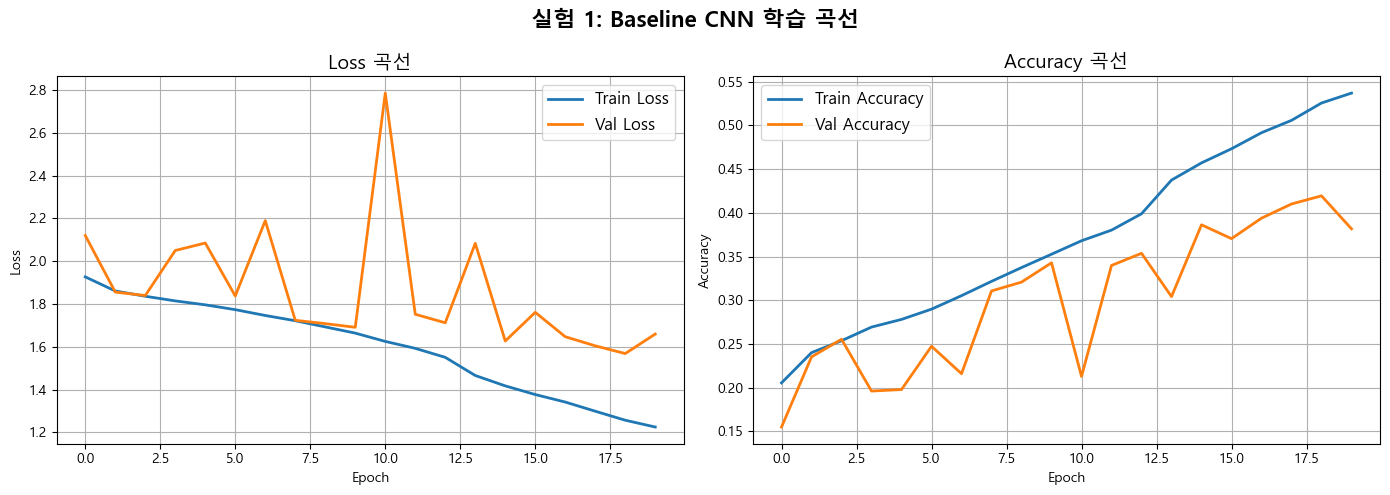

📊 학습 곡선 저장 → ..\outputs\figures\exp1_learning_curve.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 왼쪽: Loss 곡선 ──
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Loss 곡선', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=12)
axes[0].grid(True)

# ── 오른쪽: Accuracy 곡선 ──
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_title('Accuracy 곡선', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=12)
axes[1].grid(True)

plt.suptitle('실험 1: Baseline CNN 학습 곡선', fontsize=16, fontweight='bold')
plt.tight_layout()

# 그래프를 파일로 저장
plt.savefig(FIG_DIR / 'exp1_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 학습 곡선 저장 → {FIG_DIR / 'exp1_learning_curve.png'}")


## 9. 테스트 데이터 평가

학습에 한 번도 사용하지 않은 **테스트 데이터(5,250장)**로 최종 성능을 측정합니다.

`model.evaluate()`는 테스트 데이터 전체를 모델에 넣어 **loss와 accuracy**를 반환합니다.


In [14]:
print("=" * 50)
print("📝 테스트 데이터 평가")
print("=" * 50)

test_loss, test_acc = model.evaluate(test_dataset, verbose=1)  # ← tf.data Dataset

print(f"\n테스트 Loss    : {test_loss:.4f}")
print(f"테스트 Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

📝 테스트 데이터 평가
164/164 ━━━━━━━━━━━━━━━━━━━━ 91s 552ms/step - accuracy: 0.4197 - loss: 1.5931

테스트 Loss    : 1.5931
테스트 Accuracy: 0.4197 (42.0%)


## 10. 상세 평가 — Classification Report

클래스별 세부 성능을 확인합니다.

| 지표 | 의미 |
|------|------|
| **Precision** | 모델이 "A1이다"라고 예측한 것 중 실제 A1인 비율 (정밀도) |
| **Recall** | 실제 A1인 것 중 모델이 "A1이다"라고 맞춘 비율 (재현율) |
| **F1-Score** | Precision과 Recall의 조화 평균. 둘 다 높아야 높음 |
| **Support** | 해당 클래스의 실제 샘플 수 |


In [19]:
y_pred_proba = model.predict(test_dataset)  # ← tf.data Dataset
y_pred = np.argmax(y_pred_proba, axis=1)

# tf.data Dataset에서 실제 라벨 추출 (원핫인코딩 → 클래스 인덱스)
y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1) for _, labels in test_dataset
])

class_names = list(le.classes_)
LESION_MAP = {
    'A1': 'A1 구진/플라크',
    'A2': 'A2 비듬/각질',
    'A3': 'A3 태선화/색소',
    'A4': 'A4 농포/여드름',
    'A5': 'A5 미란/궤양',
    'A6': 'A6 결절/종괴',
    'A7': 'A7 무증상(정상)'
}
class_labels = [LESION_MAP[c] for c in class_names]

print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_labels))

164/164 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step
=== Classification Report ===
              precision    recall  f1-score   support

   A1 구진/플라크       0.35      0.35      0.35       749
    A2 비듬/각질       0.35      0.34      0.34       750
   A3 태선화/색소       0.40      0.42      0.41       750
   A4 농포/여드름       0.34      0.42      0.38       749
    A5 미란/궤양       0.60      0.56      0.58       750
    A6 결절/종괴       0.57      0.43      0.49       750
  A7 무증상(정상)       0.40      0.42      0.41       748

    accuracy                           0.42      5246
   macro avg       0.43      0.42      0.42      5246
weighted avg       0.43      0.42      0.42      5246



### 10-1. Confusion Matrix (혼동 행렬)

- **행(가로)**: 실제 클래스
- **열(세로)**: 모델이 예측한 클래스
- **대각선 값이 높을수록 좋음** (정답을 맞춘 것)
- 대각선 밖의 값은 **어떤 클래스를 어떤 클래스로 잘못 예측했는지** 보여줌

> 예: A2 행, A3 열에 숫자가 크면 → "A2를 A3로 자주 오분류한다"


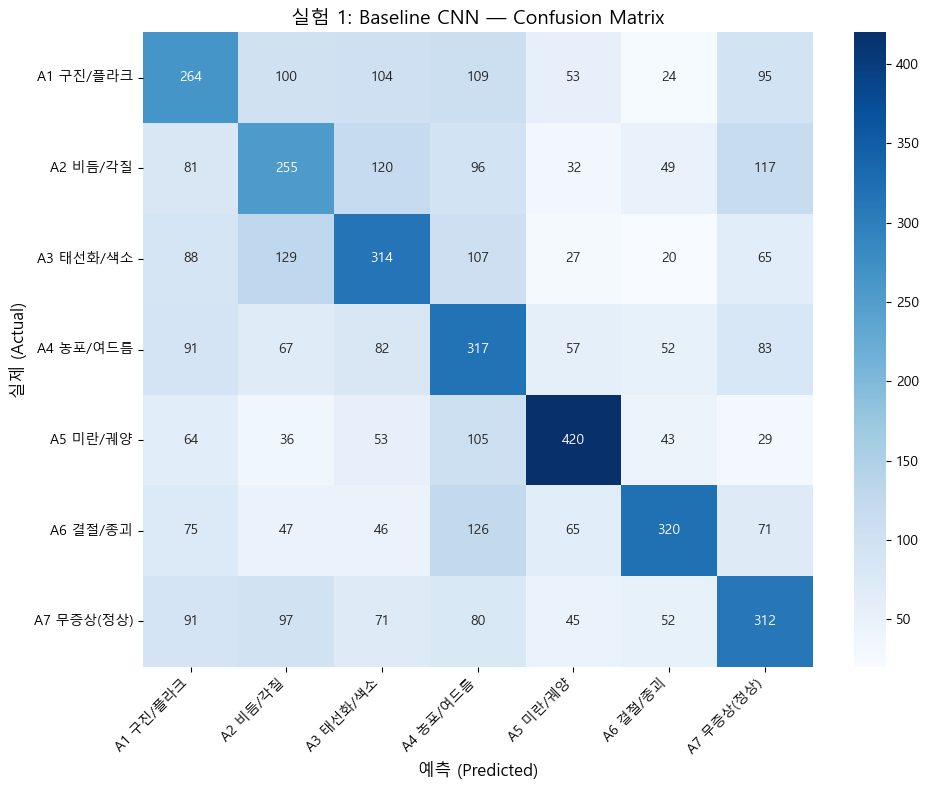

📊 혼동 행렬 저장 → ..\outputs\figures\exp1_confusion_matrix.png


In [16]:
# 혼동 행렬 계산
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_xlabel('예측 (Predicted)', fontsize=12)
ax.set_ylabel('실제 (Actual)', fontsize=12)
ax.set_title('실험 1: Baseline CNN — Confusion Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(FIG_DIR / 'exp1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 혼동 행렬 저장 → {FIG_DIR / 'exp1_confusion_matrix.png'}")


## 11. 실험 1 결과 요약

이 결과를 실험 2, 실험 3과 비교하여 최종 모델을 선정합니다.


In [17]:
print("=" * 55)
print("📋 실험 1: Baseline CNN 결과 요약")
print("=" * 55)
print(f"모델 구조       : 직접 설계 CNN (Conv2D × 4블록)")
print(f"데이터 증강     : 없음 (정규화만)")
print(f"Class Weight    : 없음")
print(f"학습 에폭       : {len(history.history['loss'])}회 (EarlyStopping 적용)")
print(f"최종 Train Loss : {history.history['loss'][-1]:.4f}")
print(f"최종 Train Acc  : {history.history['accuracy'][-1]:.4f}")
print(f"최종 Val Loss   : {history.history['val_loss'][-1]:.4f}")
print(f"최종 Val Acc    : {history.history['val_accuracy'][-1]:.4f}")
print(f"테스트 Loss     : {test_loss:.4f}")
print(f"테스트 Accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"모델 저장 경로  : models/exp1_baseline.h5")
print("=" * 55)
print()
print("→ 다음: 실험 2 (Transfer Learning + 증강)에서 성능 개선 확인")


📋 실험 1: Baseline CNN 결과 요약
모델 구조       : 직접 설계 CNN (Conv2D × 4블록)
데이터 증강     : 없음 (정규화만)
Class Weight    : 없음
학습 에폭       : 20회 (EarlyStopping 적용)
최종 Train Loss : 1.2253
최종 Train Acc  : 0.5370
최종 Val Loss   : 1.6596
최종 Val Acc    : 0.3818
테스트 Loss     : 1.5931
테스트 Accuracy : 0.4197 (42.0%)
모델 저장 경로  : models/exp1_baseline.h5

→ 다음: 실험 2 (Transfer Learning + 증강)에서 성능 개선 확인
